<Figure size 2000x1600 with 0 Axes>

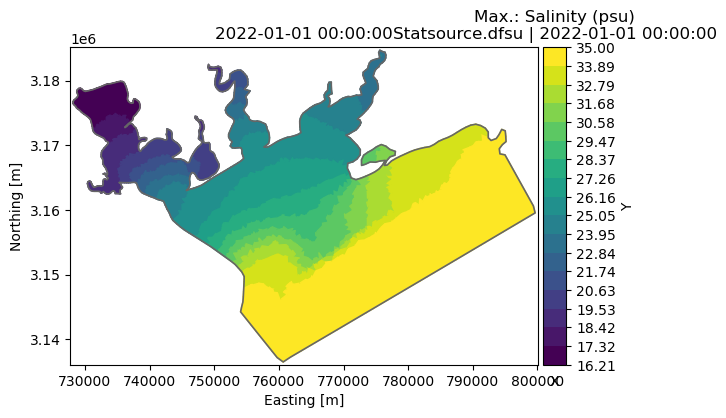

In [5]:
# pip install mikeio matplotlib numpy

import matplotlib.pyplot as plt
from mikeio import Dfsu
from pathlib import Path

# -------- USER INPUT --------
dfsu_path = r"D:\Phd Research\Salinity_Modelling\Statsource.dfsu"
time_index = 0
item_name = "Max.: Salinity"
vmin, vmax = 0.0, 35.0
levels = 18            # <-- integer (number of contour levels)
# ----------------------------

dfsu = Dfsu(dfsu_path)

# Find item
try:
    sal_idx = [i for i, it in enumerate(dfsu.items) if it.name == item_name][0]
except IndexError:
    raise RuntimeError(f"Item '{item_name}' not found. Available: {[it.name for it in dfsu.items]}")

# Read
ds = dfsu.read(items=sal_idx, time=time_index)
da = ds[0]
if "z" in da.dims:
    da = da.isel(z=0)

plt.figure(figsize=(10, 8), dpi=200)
pcm = da.plot(
    cmap="viridis",
    levels=levels,   # integer OK with vmin/vmax
    vmin=vmin,
    vmax=vmax,
    add_colorbar=True,  # if this errors in your mikeio version, try: cbar=True
)

fname = Path(dfsu_path).name
tlabel = str(ds.time[0]) if len(ds.time) else f"t={time_index}"
plt.title(f"Max.: Salinity (psu)\n{fname} | {tlabel}")
plt.xlabel("X"); plt.ylabel("Y")
plt.show()


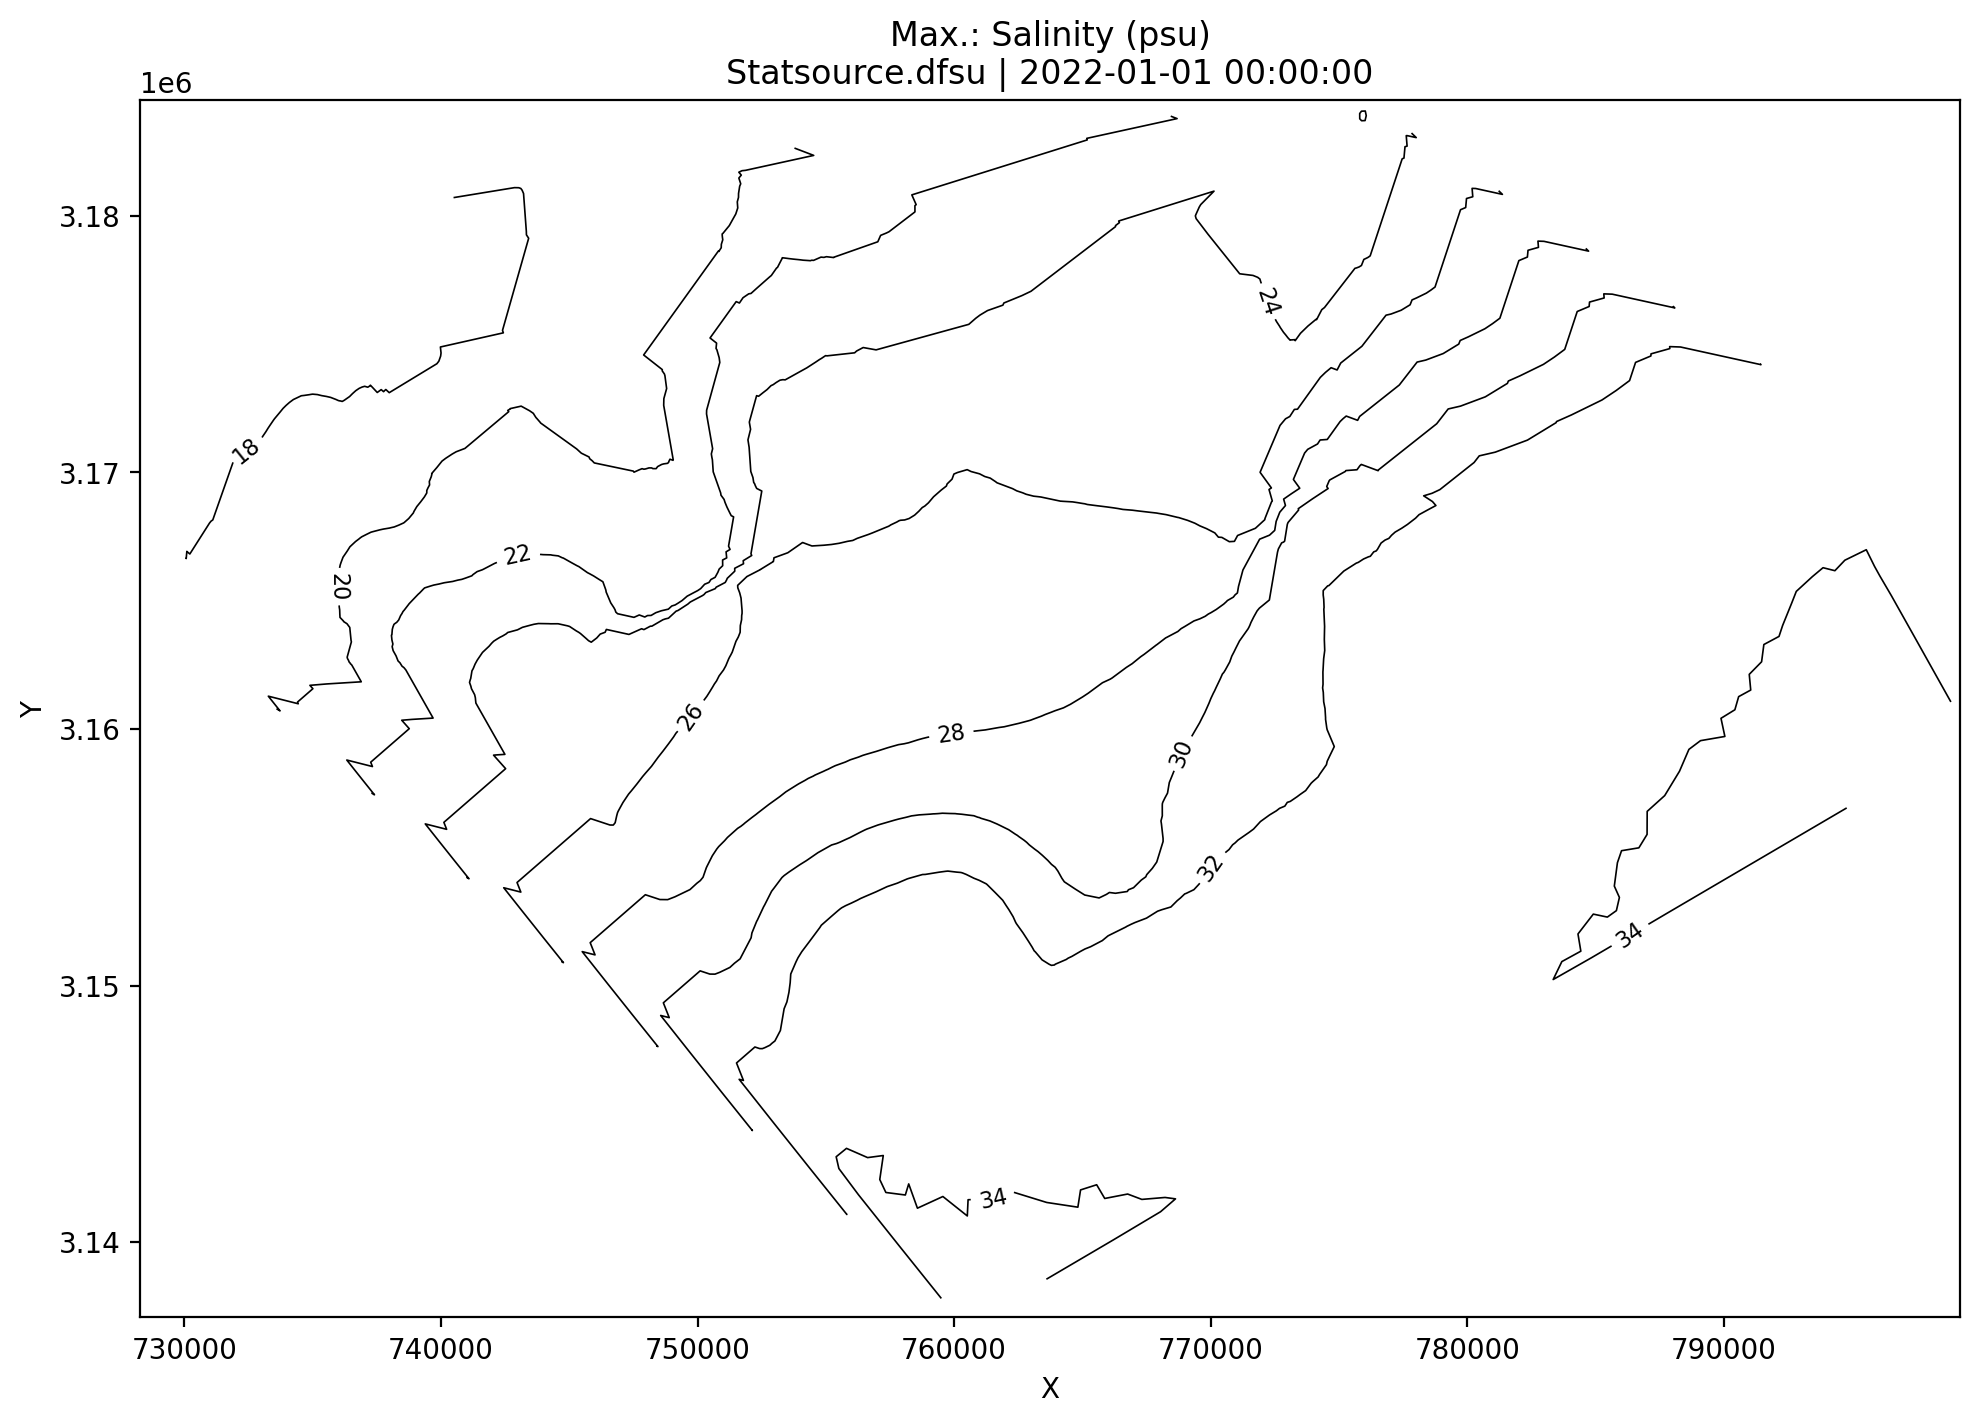

In [7]:
# --- Requirements ---
# pip install mikeio matplotlib numpy

import numpy as np
import matplotlib.pyplot as plt
from mikeio import Dfsu
from pathlib import Path

# -------- USER INPUT --------
dfsu_path = r"D:\Phd Research\Salinity_Modelling\Statsource.dfsu"
item_name = "Max.: Salinity"   # exact match
time_index = 0                 # for stats files this is usually 0
contour_step = 2.0             # psu between isolines (adjust as needed)
# ----------------------------

# Open DFSU
dfsu = Dfsu(dfsu_path)

# Find item index by exact name
try:
    sal_idx = [i for i, it in enumerate(dfsu.items) if it.name == item_name][0]
except IndexError:
    raise RuntimeError(f"Item '{item_name}' not found. Available: {[it.name for it in dfsu.items]}")

# Read data
ds = dfsu.read(items=sal_idx, time=time_index)
da = ds[0]  # DataArray (n_elements,)

# Ensure 2D (your file is 2D, but guard anyway)
if "z" in da.dims:
    raise RuntimeError("This script is for 2D DFSU. Detected a vertical (z) dimension.")

# Element-centroid coordinates (works for mixed elements)
exy = dfsu.geometry.element_coordinates  # shape (n_elements, 2)
x = exy[:, 0]
y = exy[:, 1]
z = np.asarray(da.values, dtype=float)

# Clean & level selection
mask = np.isfinite(z)
x, y, z = x[mask], y[mask], z[mask]

zmin, zmax = float(np.nanmin(z)), float(np.nanmax(z))
if not np.isfinite(zmin) or not np.isfinite(zmax):
    raise RuntimeError("No finite salinity values found to contour.")

# Build contour levels (nice rounded range)
lo = np.floor(zmin / contour_step) * contour_step
hi = np.ceil(zmax / contour_step) * contour_step
levels = np.arange(lo, hi + 0.5 * contour_step, contour_step)

# Plot
fig, ax = plt.subplots(figsize=(10, 8), dpi=200)

# Optional smooth fill underneath (comment out if you only want lines)
# cf = ax.tricontourf(x, y, z, levels=levels, cmap="viridis")

# Contour LINES
cs = ax.tricontour(x, y, z, levels=levels, colors="k", linewidths=0.6)
ax.clabel(cs, fmt="%.0f", inline=True, fontsize=8)

# Titles/labels
fname = Path(dfsu_path).name
tlabel = str(ds.time[0]) if len(ds.time) else f"t={time_index}"
ax.set_title(f"{item_name} (psu)\n{fname} | {tlabel}")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_aspect("equal")  # better geometry proportions

plt.tight_layout()
plt.show()


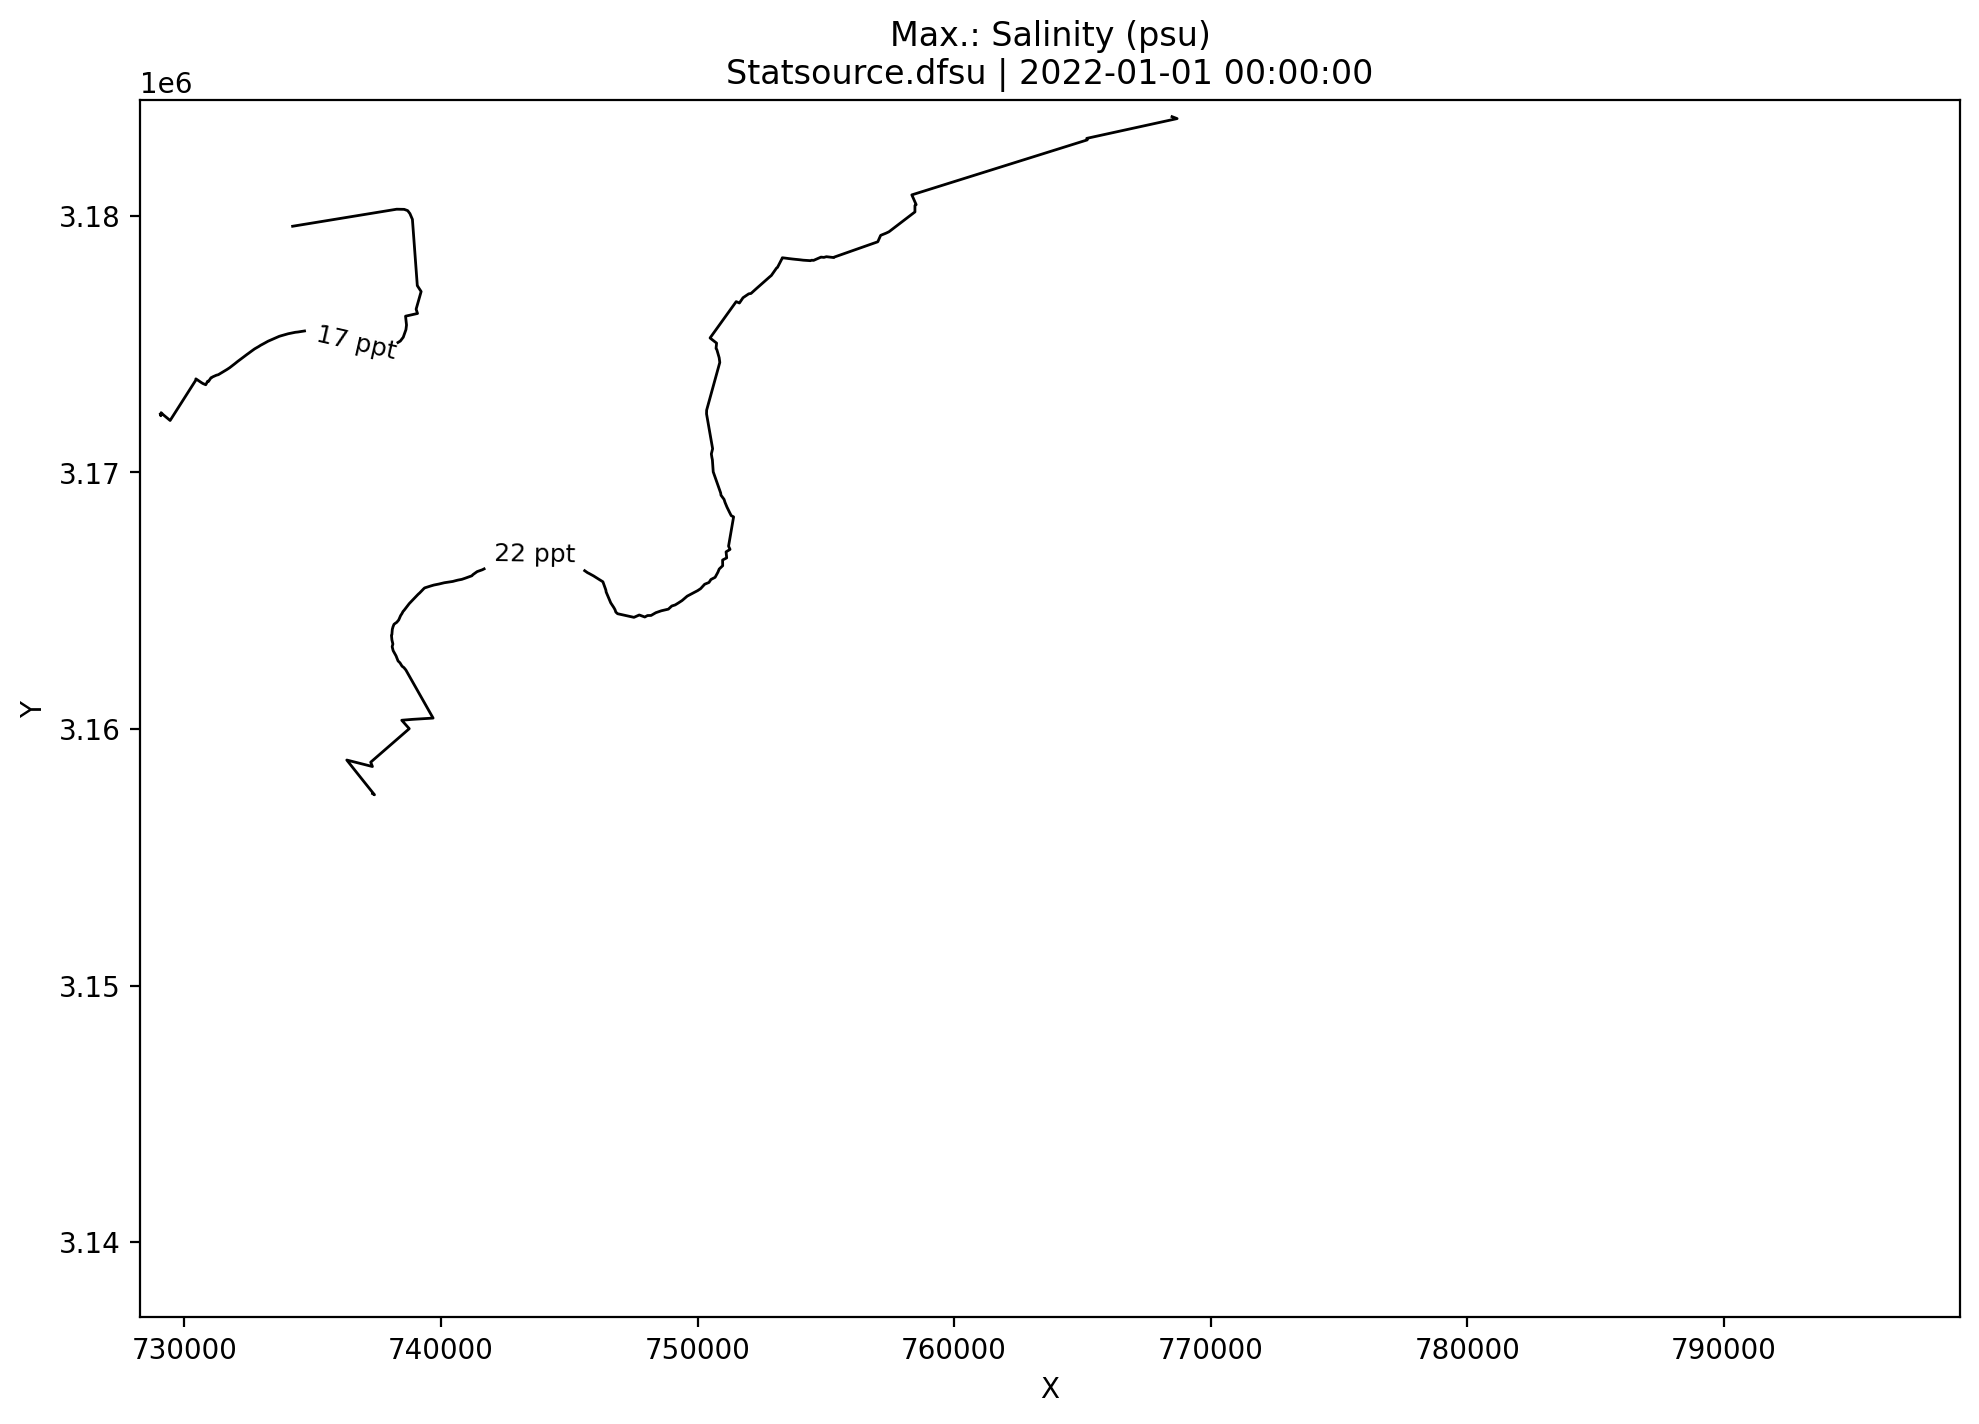

In [8]:
# --- Requirements ---
# pip install mikeio matplotlib numpy

import numpy as np
import matplotlib.pyplot as plt
from mikeio import Dfsu
from pathlib import Path

# -------- USER INPUT --------
dfsu_path = r"D:\Phd Research\Salinity_Modelling\Statsource.dfsu"
item_name = "Max.: Salinity"   # exact match
time_index = 0                 # for stats files this is usually 0
target_levels = [13, 17, 22]   # ppt contour levels
# ----------------------------

# Open DFSU
dfsu = Dfsu(dfsu_path)

# Find item index
try:
    sal_idx = [i for i, it in enumerate(dfsu.items) if it.name == item_name][0]
except IndexError:
    raise RuntimeError(f"Item '{item_name}' not found. Available: {[it.name for it in dfsu.items]}")

# Read data
ds = dfsu.read(items=sal_idx, time=time_index)
da = ds[0]

# Ensure 2D
if "z" in da.dims:
    raise RuntimeError("This script is for 2D DFSU. Detected a vertical (z) dimension.")

# Element centroids
exy = dfsu.geometry.element_coordinates
x = exy[:, 0]
y = exy[:, 1]
z = np.asarray(da.values, dtype=float)

# Mask bad values
mask = np.isfinite(z)
x, y, z = x[mask], y[mask], z[mask]

# Plot
fig, ax = plt.subplots(figsize=(10, 8), dpi=200)

# Draw contours only at specified levels
cs = ax.tricontour(x, y, z, levels=target_levels, colors="k", linewidths=1.0)
ax.clabel(cs, fmt="%.0f ppt", inline=True, fontsize=9)

# Labels
fname = Path(dfsu_path).name
tlabel = str(ds.time[0]) if len(ds.time) else f"t={time_index}"
ax.set_title(f"{item_name} (psu)\n{fname} | {tlabel}")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_aspect("equal")

plt.tight_layout()
plt.show()


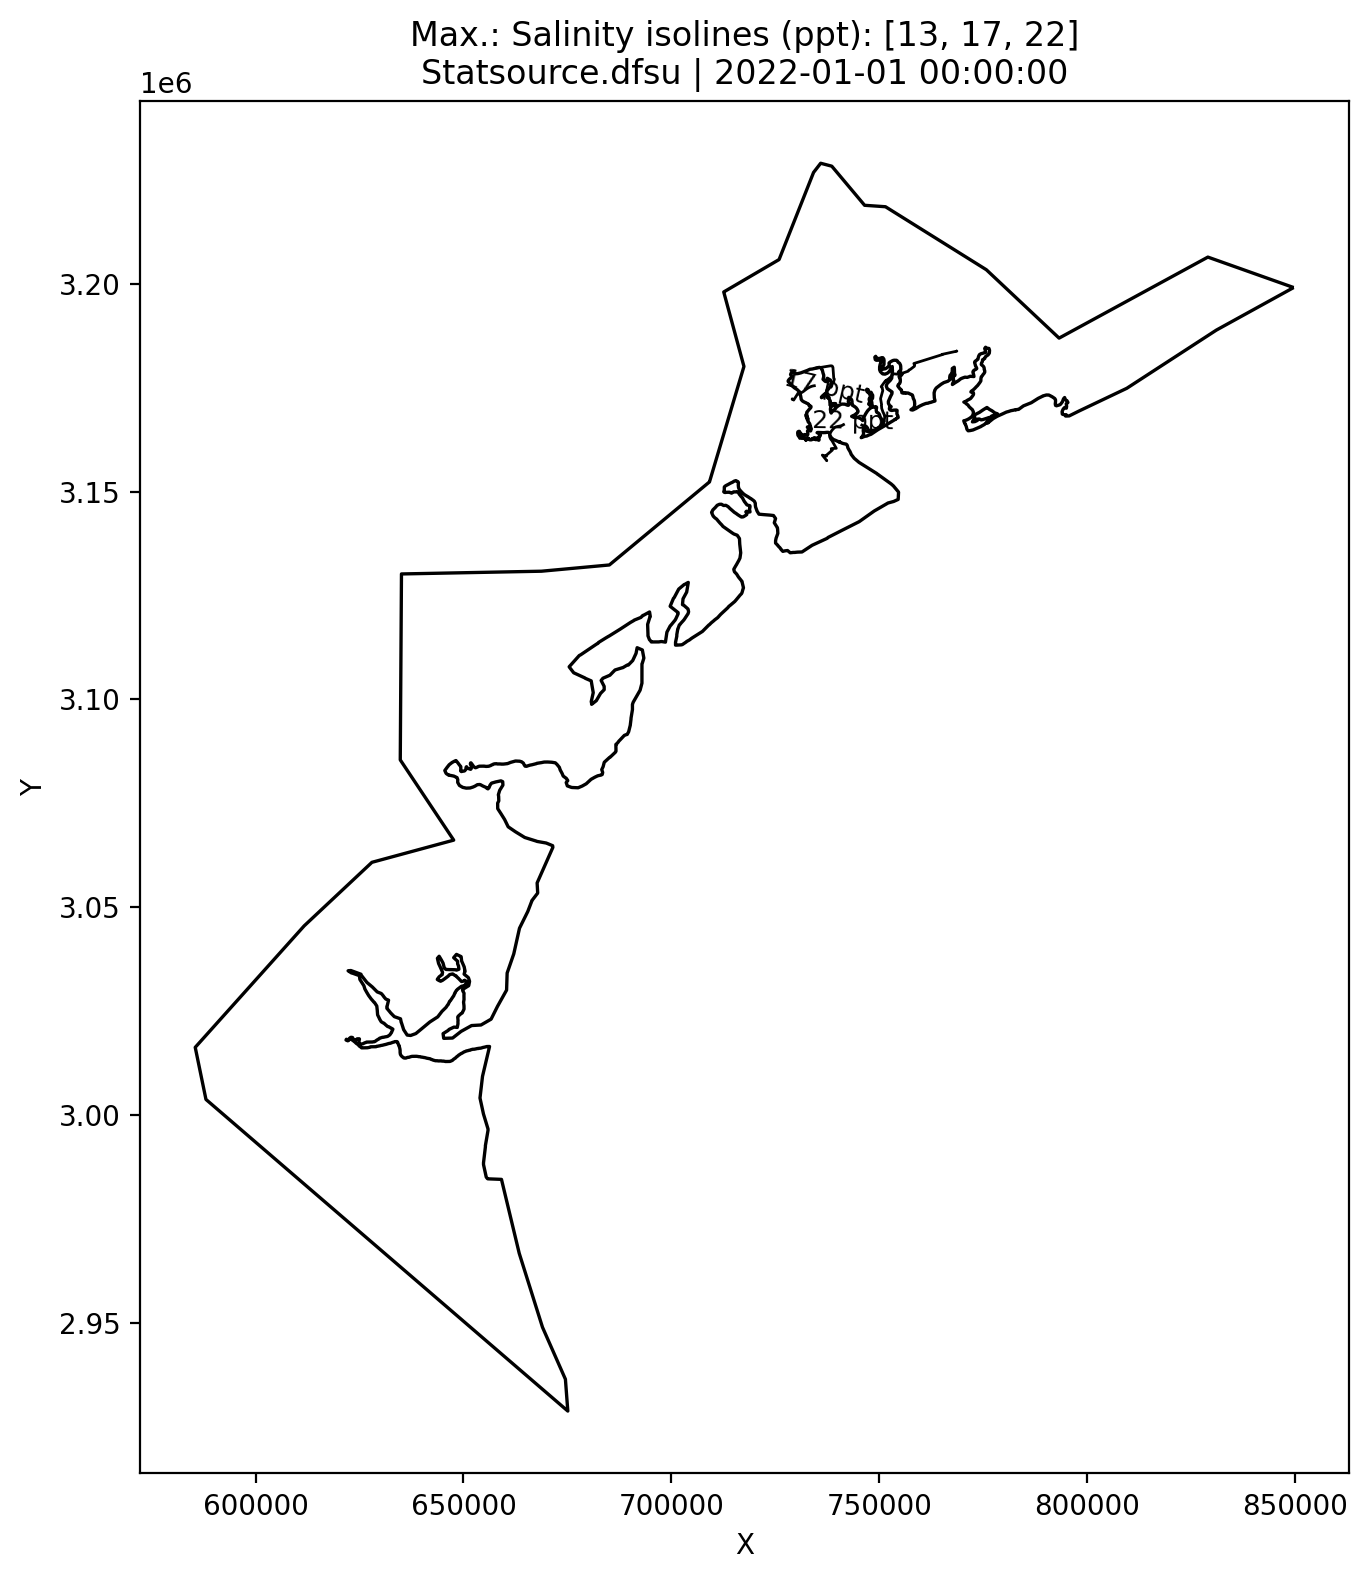

In [11]:
# --- Requirements ---
# pip install mikeio matplotlib numpy geopandas

import numpy as np
import matplotlib.pyplot as plt
from mikeio import Dfsu
from pathlib import Path
import geopandas as gpd

# -------- USER INPUT --------
dfsu_path   = r"D:\Phd Research\Salinity_Modelling\Statsource.dfsu"
item_name   = "Max.: Salinity"   # exact match
time_index  = 0                  # for stats files this is usually 0
levels_ppt  = [13, 17, 22]       # contour lines (ppt)
shp_zip     = r"D:\Phd Research\GIS\Shape\land_Part_area_utm.zip"
# ----------------------------

# Open DFSU
dfsu = Dfsu(dfsu_path)

# Find item index
try:
    sal_idx = next(i for i, it in enumerate(dfsu.items) if it.name == item_name)
except StopIteration:
    raise RuntimeError(f"Item '{item_name}' not found. Available: {[it.name for it in dfsu.items]}")

# Read data
ds = dfsu.read(items=sal_idx, time=time_index)
da = ds[0]  # 2D expected

# Guard against 3D
if "z" in da.dims:
    raise RuntimeError("Detected vertical (z) dimension; this script is for 2D DFSU files.")

# Geometry (element centroids for robust unstructured contouring)
exy = dfsu.geometry.element_coordinates  # (n_elements, 2)
x = exy[:, 0]
y = exy[:, 1]
z = np.asarray(da.values, dtype=float)

# Mask invalid
m = np.isfinite(z)
x, y, z = x[m], y[m], z[m]

# Prepare plot
fig, ax = plt.subplots(figsize=(10, 8), dpi=200)

# Draw ONLY the requested contour lines
cs = ax.tricontour(x, y, z, levels=levels_ppt, colors="k", linewidths=1.0)
ax.clabel(cs, fmt="%.0f ppt", inline=True, fontsize=9)

# ---- Overlay boundary from zipped shapefile ----
try:
    gdf = gpd.read_file(shp_zip)
    # Try to reproject to DFSU CRS if available
    target_crs = None
    try:
        # mikeio stores a projection object or string; both are acceptable to GeoPandas
        target_crs = str(dfsu.geometry.projection) if dfsu.geometry.projection is not None else None
    except Exception:
        target_crs = None

    if target_crs and gdf.crs is not None:
        gdf = gdf.to_crs(target_crs)

    # Draw boundary on top (no fill)
    gdf.boundary.plot(ax=ax, color="black", linewidth=1.2, zorder=10)
except Exception as e:
    print(f"Boundary overlay skipped ({e})")

# Labels / title
fname = Path(dfsu_path).name
tlabel = str(ds.time[0]) if len(ds.time) else f"t={time_index}"
ax.set_title(f"{item_name} isolines (ppt): {levels_ppt}\n{fname} | {tlabel}")
ax.set_xlabel("X"); ax.set_ylabel("Y")
ax.set_aspect("equal")
plt.tight_layout()
plt.show()


C:\Users\sahad2\AppData\Local\Temp\ipykernel_20752\546810918.py:54: UserWarning: Glyph 9135 (\N{HORIZONTAL LINE EXTENSION}) missing from current font.
  plt.tight_layout()
C:\Program Files\ArcGIS\Pro\bin\Python\envs\arcgispro-py3\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 9135 (\N{HORIZONTAL LINE EXTENSION}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


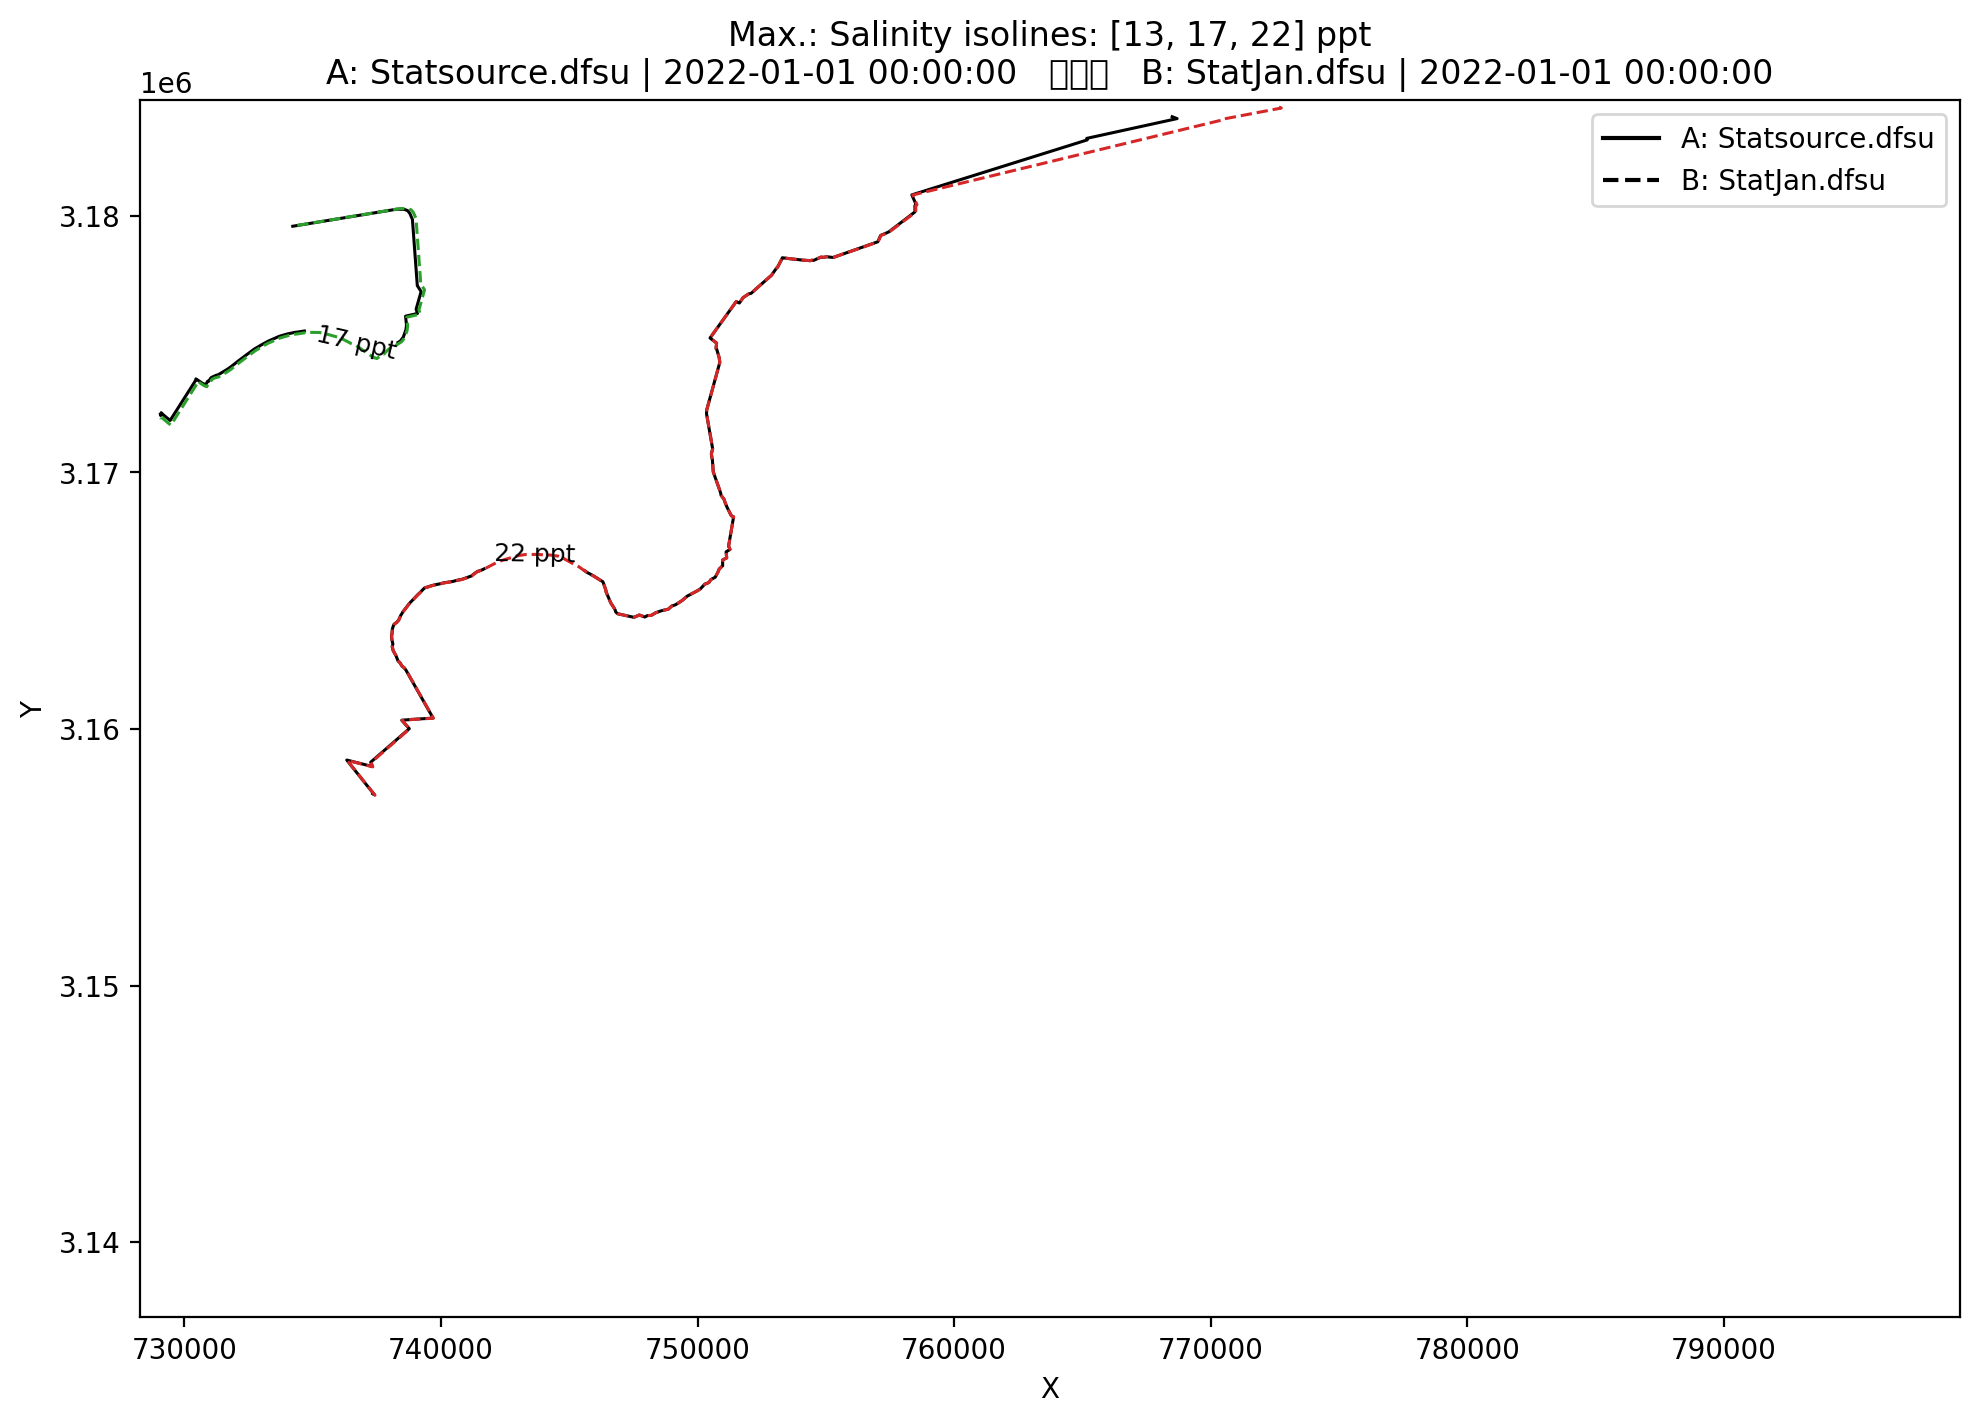

In [12]:
# --- Requirements ---
# pip install mikeio matplotlib numpy

import numpy as np
import matplotlib.pyplot as plt
from mikeio import Dfsu
from pathlib import Path
from matplotlib.lines import Line2D

# -------- USER INPUT --------
dfsu_a = r"D:\Phd Research\Salinity_Modelling\Statsource.dfsu"  # base file
dfsu_b = r"D:\Phd Research\Salinity_Modelling\StatJan.dfsu"     # overlay file
item_name = "Max.: Salinity"   # exact match
time_index = 0                 # for stats files this is usually 0
target_levels = [13, 17, 22]   # ppt isolines
# ----------------------------

def read_item_centroids(dfsu_path, item_name, time_index=0):
    d = Dfsu(dfsu_path)
    try:
        idx = next(i for i, it in enumerate(d.items) if it.name == item_name)
    except StopIteration:
        raise RuntimeError(f"Item '{item_name}' not found in {dfsu_path}. "
                           f"Available: {[it.name for it in d.items]}")
    ds = d.read(items=idx, time=time_index)
    da = ds[0]
    if "z" in da.dims:
        raise RuntimeError(f"{Path(dfsu_path).name} appears 3D (has 'z'). This script expects 2D DFSU.")
    exy = d.geometry.element_coordinates  # (n_elems, 2)
    x = exy[:, 0]; y = exy[:, 1]
    z = np.asarray(da.values, dtype=float)
    m = np.isfinite(z)
    return x[m], y[m], z[m], Path(dfsu_path).name, (str(ds.time[0]) if len(ds.time) else f"t={time_index}")

# Read both datasets
xA, yA, zA, nameA, tA = read_item_centroids(dfsu_a, item_name, time_index)
xB, yB, zB, nameB, tB = read_item_centroids(dfsu_b, item_name, time_index)

# Plot
fig, ax = plt.subplots(figsize=(10, 8), dpi=200)

# A: solid black
csA = ax.tricontour(xA, yA, zA, levels=target_levels, colors="k", linewidths=1.1)
ax.clabel(csA, fmt="%.0f ppt", inline=True, fontsize=9)

# B: dashed colored (same levels)
csB = ax.tricontour(xB, yB, zB, levels=target_levels, colors=["tab:blue","tab:green","tab:red"], linestyles="--", linewidths=1.1)

# Title/axes
ax.set_title(f"{item_name} isolines: {target_levels} ppt\nA: {nameA} | {tA}   ⎯⎯⎯   B: {nameB} | {tB}")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_aspect("equal")
plt.tight_layout()

# Legend: two proxies (solid = A, dashed = B)
legend_handles = [
    Line2D([0], [0], color="k", lw=1.5, linestyle="-", label=f"A: {nameA}"),
    Line2D([0], [0], color="k", lw=1.5, linestyle="--", label=f"B: {nameB}"),
]
ax.legend(handles=legend_handles, loc="best", frameon=True)

plt.show()
